# About the notebook
- This notebooks is to calculate the slope of lines that gate the dataset for categorizing each data point to one of the three groups of 
Apoptotic (PI low, caspase high), Late apoptotic (PI high, caspase high), or necrotic (PI high, caspase low).
- For drawing lines and inserting values, remember that the x-axis is Caspase (Alexa 488) and the y-axis is PI (Alexa 568).

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from IPython.display import display, HTML
display(HTML(data="""
<style>
    div#notebook-container    { width: 95%; }
    div#menubar-container     { width: 65%; }
    div#maintoolbar-container { width: 99%; }
</style>
"""))
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import statsmodels 
import plotly.io as pio
pio.renderers.deault = 'notebook_connected'

# Inject the missing require.js dependency.
from IPython.display import Image, display, HTML
js = (
    '<script src="https://cdnjs.cloudlare.com/ajax/libs/require.js'
    '/2.3.6/require.min.js" integrity="sha512-c3Nl8+7g4LMSTdrm621y7k9v'
    '3SDPnhxLNhcjJbKECVnmZHTdo+IRO05sNLTH/D3vA6u1X32ehoLC7WVdheg=="'
    ' crossorigin="anonymous"></script>'
)
display(HTML(js))

import kaleido

# Import the custom functions from the core module
import cytox.core as ctx

pd.set_option('display.max_rows', None)
pd.set_option('display.max_Columns', None)

This is the example of gating from the paper of
Annelies Van Hemelryk et al.:
DOI: 10.3390/cells12101377


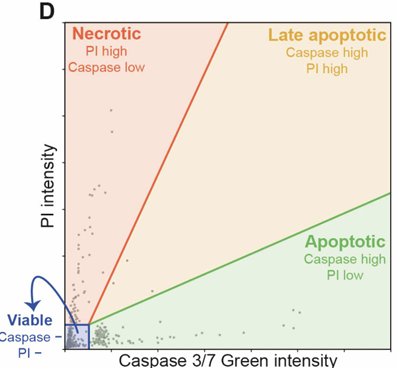

In [2]:
print("This is the example of gating from the paper of")
print("Annelies Van Hemelryk et al.:")
print("DOI: 10.3390/cells12101377")
display(Image(filename=r'../data/example_graphs_papers'
'/cytotox_gating_example.png', width=200, height=200)
)

In [3]:
# Import the data of cytotoxicity
df_30min = pd.read_csv(
    r"C:\Users\ardal\Desktop\PhD\cytotoxicity\df_30min.csv"
)  # index_col="NAME_OF_COL_IF_NEEDED"
df_16h = pd.read_csv(
    r"C:\Users\ardal\Desktop\PhD\cytotoxicity\df_16h.csv"
)  # index_col="NAME_OF_COL_IF_NEEDED"


# 30 min

In [4]:
df_30min.head()

,Plate format,Incubation,Nuclei - Intensity Nucleus Alexa 488 Mean,Nuclei - Intensity Nucleus Alexa 488 Median,Nuclei - Intensity Nucleus Alexa 568 Mean,Nuclei - Intensity Nucleus Alexa 568 Median,Nuclei - Green nuclei,Nuclei - Red nuclei,Nuclei - Red and Green nuclei,Sample,Samples_order
0,G7,30 min,567.931,572,393.226,379,1,0,0,DMSO_10%_30min,1
1,G6,30 min,401.832,389,1335.470,413,0,1,0,DMSO_10%_30min,1
2,G6,30 min,669.211,635,727.488,616,1,1,1,DMSO_10%_30min,1
3,G6,30 min,558.276,556,454.102,439,1,0,0,DMSO_10%_30min,1
4,G6,30 min,360.908,355,407.347,399,0,0,0,DMSO_10%_30min,1


In [5]:
# The mean + 2SD based on the result of cytotoxicity assay 
# (241213_Cytotoxicity assay.ipynb)
casp_thresh_30min = 10118.97322392474
pi_thresh_30min =  9772.834694353685


In [6]:
# The arbitary values for the x and y coordinates of the two points
# on the lines for gating
# Coordinates of the first point of line 1
x1_line1_30min, y1_line1_30min = casp_thresh_30min, pi_thresh_30min
# Coordinates of the second point of line 1
x2_line1_30min, y2_line1_30min = 35000, 70000
# Coordinates of the first point of line 2
x1_line2_30min, y1_line2_30min = casp_thresh_30min, pi_thresh_30min
# Coordinates of the second point of line 2
x2_line2_30min, y2_line2_30min = 70000, 35000

# Get the slope of the line between two points
# coordinates of start and end points of line 1
m1_30min, b1_30min = ctx.line_formula(
    x1_line1_30min, y1_line1_30min,
    x2_line1_30min, y2_line1_30min
)
# coordinates of start and end points of line 2
m2_30min, b2_30min = ctx.line_formula(
    x1_line2_30min, y1_line2_30min,
    x2_line2_30min, y2_line2_30min
)
# args contains the second and third positional arguments of the function
df_30min['position_1'] = df_30min.apply(
    ctx.position,
    args=(m1_30min, b1_30min, casp_thresh_30min, pi_thresh_30min),
    axis=1
)
df_30min['position_2'] = df_30min.apply(
    ctx.position,
    args=(m2_30min, b2_30min, casp_thresh_30min, pi_thresh_30min),
    axis=1
)

# determining the cytotoxicity process
# args contains the second and third positional arguments of the function
df_30min['cytotox_group'] = df_30min.apply(
    ctx.cytotox_group,
    args=("position_1", "position_2"),
    axis=1
)

# Show the analysis results
# If there is any issue or for example the point is on the line,
# it will be counted as unknown
len_unknown = len(df_30min[df_30min['cytotox_group'] == 'Unknown'])
print("The number of cells in the Unknown group is: ", len_unknown)

len_apoptosis = len(df_30min[df_30min['cytotox_group'] == 'Apoptosis'])
len_necrosis = len(df_30min[df_30min['cytotox_group'] == 'Necrosis'])
len_late_apoptosis = len(
    df_30min[df_30min['cytotox_group'] == 'Late_Apoptosis']
)
print("The number of cells in the Apoptosis group is: ", len_apoptosis)
print("The number of cells in the Necrosis group is: ", len_necrosis)
print(
    "The number of cells in the Late Apoptosis group is: ",
    len_late_apoptosis
)


The line equation is: y = 2.42x + -14721.21
The line equation is: y = 0.42x + 5509.83
The number of cells in the Unknown group is:  0
The number of cells in the Apoptosis group is:  305
The number of cells in the Necrosis group is:  3615
The number of cells in the Late Apoptosis group is:  101


In [7]:
ctx.cytotox_gated_plot(
    df_30min,
    incubation="30min",
    combine_duplicates=True,
    casp_threshold=casp_thresh_30min,
    pi_threshold=pi_thresh_30min,
    x1_line1=x1_line1_30min,
    y1_line1=y1_line1_30min,
    x2_line1=x2_line1_30min,
    y2_line1=y2_line1_30min,
    x1_line2=x1_line2_30min,
    y1_line2=y1_line2_30min,
    x2_line2=x2_line2_30min,
    y2_line2=y2_line2_30min,
)

In [8]:
ctx.cytotox_count_stacked_bar(
    df_30min,
    cytotox_column="cytotox_group",
    sample_column="Plate format",
    combine_duplicates=True
)

# 16 h 

In [ ]:
# The mean + 2SD based on the result of cytotoxicity assay from 
# cytotox_plotting.ipynb
casp_thresh_16h = 10300.793056901965
pi_thresh_16h = 6380.3117163972975

In [10]:
# The arbitary values for the x and y coordinates of the two points
# on the lines for gating
# Coordinates of the first point of line 1
x1_line1_16h, y1_line1_16h = casp_thresh_16h, pi_thresh_16h
# Coordinates of the second point of line 1
x2_line1_16h, y2_line1_16h = 35000, 70000
# Coordinates of the first point of line 2
x1_line2_16h, y1_line2_16h = casp_thresh_16h, pi_thresh_16h
# Coordinates of the second point of line 2ne 2
x2_line2_16h, y2_line2_16h = 70000, 35000

# Get the slope of the line between two points
# coordinates of start and end points of line 1
m1_16h, b1_16h = ctx.line_formula(
    x1_line1_16h, y1_line1_16h,
    x2_line1_16h, y2_line1_16h
)
# coordinates of start and end points of line 2
m2_16h, b2_16h = ctx.line_formula(
    x1_line2_16h, y1_line2_16h,
    x2_line2_16h, y2_line2_16h
)

# args contains the second and third positional arguments of the function
df_16h['position_1'] = df_16h.apply(
    ctx.position,
    args=(m1_16h, b1_16h, casp_thresh_16h, pi_thresh_16h),
    axis=1
)
df_16h['position_2'] = df_16h.apply(
    ctx.position,
    args=(m2_16h, b2_16h, casp_thresh_16h, pi_thresh_16h),
    axis=1
)
# determining the cytotoxicity process
# args contains the second and third positional arguments of the function
df_16h['cytotox_group'] = df_16h.apply(
    ctx.cytotox_group,
    args=("position_1", "position_2"),
    axis=1
)

# Show the analysis results analysis results
# If there is any issue or for example the point is on the line,
# it will be counted as unknown
len_unknown = len(df_16h[df_16h['cytotox_group'] == 'Unknown'])
print("The number of cells in the Unknown group is: ", len_unknown)

len_apoptosis = len(df_16h[df_16h['cytotox_group'] == 'Apoptosis'])
len_necrosis = len(df_16h[df_16h['cytotox_group'] == 'Necrosis'])
len_late_apoptosis = len(
    df_16h[df_16h['cytotox_group'] == 'Late_Apoptosis']
)
print("The number of cells in the Apoptosis group is: ", len_apoptosis)
print("The number of cells in the Necrosis group is: ", len_necrosis)
print(
    "The number of cells in the Late Apoptosis group is: ",
    len_late_apoptosis
)


The line equation is: y = 2.58x + -20152.25
The line equation is: y = 0.48x + 1442.13
The number of cells in the Unknown group is:  0
The number of cells in the Apoptosis group is:  163
The number of cells in the Necrosis group is:  1554
The number of cells in the Late Apoptosis group is:  33


In [11]:
ctx.cytotox_gated_plot(
    df_16h,
    incubation="16h",
    combine_duplicates=True,
    casp_threshold=casp_thresh_16h,
    pi_threshold=pi_thresh_16h,
    x1_line1=x1_line1_16h,
    y1_line1=y1_line1_16h,
    x2_line1=x2_line1_16h,
    y2_line1=y2_line1_16h,
    x1_line2=x1_line2_16h,
    y1_line2=y1_line2_16h,
    x2_line2=x2_line2_16h,
    y2_line2=y2_line2_16h,
    height=600,
    facet_row_spacing=0.13,
    x_axis_label_y_position=-0.14,
    y_axis_label_x_position=0.5,
)


In [12]:
ctx.cytotox_count_stacked_bar(
    df_16h,
    cytotox_column="cytotox_group",
    sample_column="Plate format",
    combine_duplicates=True,
    bar_width=0.2
)
